In [17]:
import json
import matplotlib.pyplot as plt
import numpy as np
import re
experiments = ["codecontests", "connections", "sequences"]
ops = ["BASE", "REFLECTIVE", "ITERATIVE", "FEEDBACK","PARAPHRASE"]
tok_pattern = r"""Token checkpoint: (\w+) - Prompt tokens: (\d+), Completion tokens: (\d+)\s*.* INFO - Token checkpoint: (\w+) - Prompt tokens: (\d+), Completion tokens: (\d+)"""

all_data = {}
for exp in experiments:
    exp_data = {}
    for op in ops:
        with open(f"finished_experiments/{exp}1_{op}/prompts.jsonl") as f:
            prompts = [json.loads(line) for line in f]
        with open(f"finished_experiments/{exp}1_{op}/task_attempts.json") as f:
            task_attempts = json.load(f)
        with open(f"finished_experiments/{exp}1_{op}/model_api.log") as f:
            matches = re.findall(tok_pattern, f.read())
        token_checkpoints = {}
        if len(matches) == 3:
            for m in matches:
                for i in range(2):
                    token_checkpoints[m[3*i]] = {
                        "prompt_tokens": int(m[3*i+1]),
                        "completion_tokens": int(m[3*i+2]),
                    }


        exp_data[op] = {
            "prompts": prompts,
            "task_attempts": task_attempts,
            "token_checkpoints": token_checkpoints,
        }

    all_data[exp] = exp_data


In [18]:
from textwrap import dedent
table = dedent(r"""
\begin{table}[htbp]
    \centering
    \captionsetup{font=small}
    \caption{<NAME>}  
    \label{<LABEL>}
    \renewcommand{\arraystretch}{1.4} % row spacing
    
    \begin{tabular}{|c||c|c|c|c|}
    \hline
    \rowcolor{ctublue!10}
    \textbf{Step} &
    \cellcolor{ctulightblue}\textbf{Reflective} &
    \cellcolor{ctulightblue}\textbf{Iterative} &
    \cellcolor{ctulightblue}\textbf{Feedback} &
    \cellcolor{ctulightblue}\textbf{Paraphrase} \\
    \hline
    
    \rowcolor{ctuorange!20}
    <DATA>
    
    \end{tabular}
\end{table}
""")

In [28]:
tables = []
op_performance = {k: [[] for _ in range(10)] for k in all_data["connections"].keys() if k != "BASE"}
for exp, exp_data in all_data.items():
    print(f"Processing {exp}...")
    baseline = exp_data["BASE"]["prompts"]
    baseline_scores = np.array([p["test_score"] for p in baseline])
    baseline_scores.sort()
    bs_score = baseline_scores[-1]
    init_score = baseline_scores[-11]
    data = f"Baseline & ${bs_score:.2f}$ & ${bs_score:.2f}$ & ${bs_score:.2f}$ & ${bs_score:.2f}$ \\\\ \\hline\n"
    data += f"Initial & ${init_score:.2f}$ & ${init_score:.2f}$ & ${init_score:.2f}$ & ${init_score:.2f}$ \\\\ \\hline\n"
    best_in_op = {k: (bs_score, -1) for k in exp_data.keys()}
    for gen in range(1,11):
        data += f"${gen}$ "
        for op, op_data in exp_data.items():
            if op == "BASE":
                continue
            gen_prompts = [p for p in exp_data[op]["prompts"] if p["gen"] == gen]
            if len(gen_prompts) == 0:
                continue
            scores = np.array([p["test_score"] for p in gen_prompts])
            op_score = np.max(scores)
            if op_score > best_in_op[op][0]:
                best_in_op[op] = (op_score, gen)
            data += f"& ${op_score:.2f}$ "
            print(f"{exp}: Adding {op_score} for {op} in gen {gen}")
            op_performance[op][gen-1].append(op_score / bs_score)
        data += "\\\\ \\hline\n"
    #data += f"BEST & {best_in_op['REFLECTIVE'][0]:.2f} & {best_in_op['ITERATIVE'][0]:.2f} & {best_in_op['FEEDBACK'][0]:.2f} & {best_in_op['PARAPHRASE'][0]:.2f} \\\\ \\hline\n"
    new_table = table.replace("<DATA>", data)
    new_table = new_table.replace("<NAME>", f"Results on {exp} dataset for different optimization operators")
    new_table = new_table.replace("<LABEL>", f"tab:results_{exp}")
    #with open("tables.tex", "a+") as f:
    #    f.write(new_table)

op_performance = {k: [sum(s)/len(s) for s in v] for k,v in op_performance.items()}



Processing codecontests...
codecontests: Adding 0.29397329483940815 for REFLECTIVE in gen 1
codecontests: Adding 0.16338235294117648 for ITERATIVE in gen 1
codecontests: Adding 0.1972085889570552 for FEEDBACK in gen 1
codecontests: Adding 0.2993546514364615 for PARAPHRASE in gen 1
codecontests: Adding 0.2025475720079027 for REFLECTIVE in gen 2
codecontests: Adding 0.26426470588235296 for ITERATIVE in gen 2
codecontests: Adding 0.12249999999999997 for FEEDBACK in gen 2
codecontests: Adding 0.1377941176470588 for PARAPHRASE in gen 2
codecontests: Adding 0.18699119765270739 for REFLECTIVE in gen 3
codecontests: Adding 0.11415644171779141 for ITERATIVE in gen 3
codecontests: Adding 0.12999999999999998 for FEEDBACK in gen 3
codecontests: Adding 0.20403374233128835 for PARAPHRASE in gen 3
codecontests: Adding 0.22229084219733442 for REFLECTIVE in gen 4
codecontests: Adding 0.2980547468025372 for ITERATIVE in gen 4
codecontests: Adding 0.1425 for FEEDBACK in gen 4
codecontests: Adding 0.26003

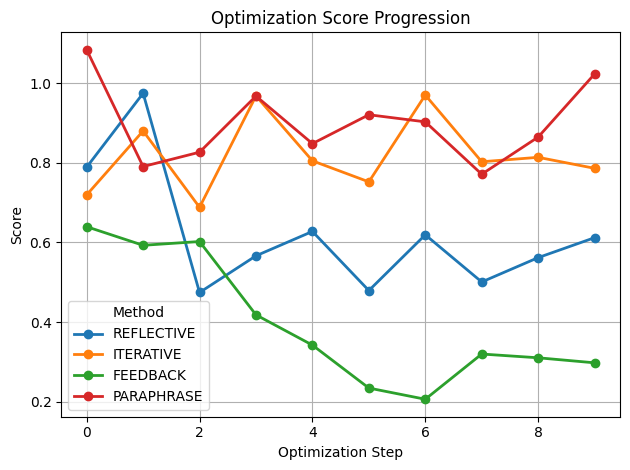

In [29]:
import pandas as pd
import plotly.express as px


df = pd.DataFrame(op_performance)

df.plot(marker='o', linewidth=2)
plt.title("Optimization Score Progression")
plt.xlabel("Optimization Step")
plt.ylabel("Score")
plt.grid(True)
plt.legend(title="Method")
plt.tight_layout()
plt.show()